In [1]:
import os
import json
import matplotlib.pyplot as plt
from src.utility_plot import display_plots_for_configs, plot_hyperparameter_vs_metric
from src.utility_functions import load_configs

In [2]:
is_developing = True
output_dir = './output/test_case_7'
config_dir = './config/test_case_7'
# Enable autoreload extension for Jupyter notebook
# This allows changes in imported modules to be reloaded automatically
if is_developing is True:
    %load_ext autoreload
    %autoreload 2

In [3]:
plots_dir = os.path.join(output_dir, "plots")
log_file_path = os.path.join(output_dir, "val_results_log.txt")

# Read log file
results = []
with open(log_file_path, 'r') as log_file:
    for line in log_file:
        parts = line.strip().split(': ')
        index = int(parts[0])
        meanARE = float(parts[2])
        maxARE = float(parts[4])
        results.append((index, meanARE, maxARE))

In [4]:
# Load configurations
configs = {}
for index, meanARE, maxARE in results:
    config_filepath = os.path.join(config_dir, f"{index}.json")
    if os.path.exists(config_filepath):  # Check if config file exists
        with open(config_filepath, 'r') as f:
            config = json.load(f)
            configs[index] = config

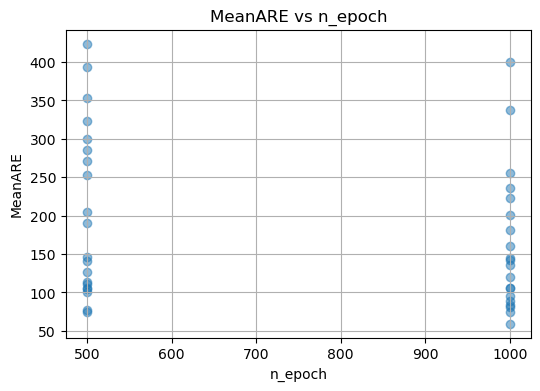

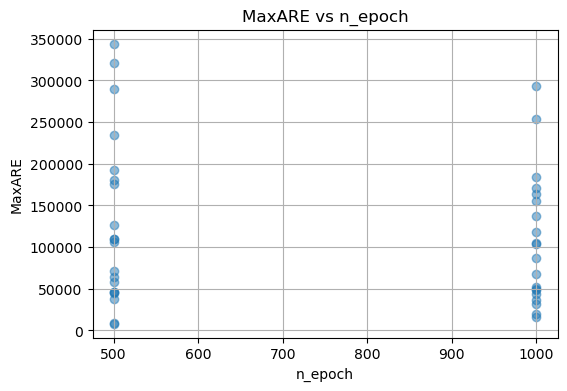

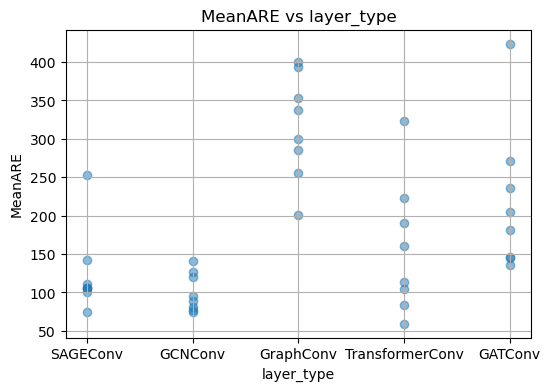

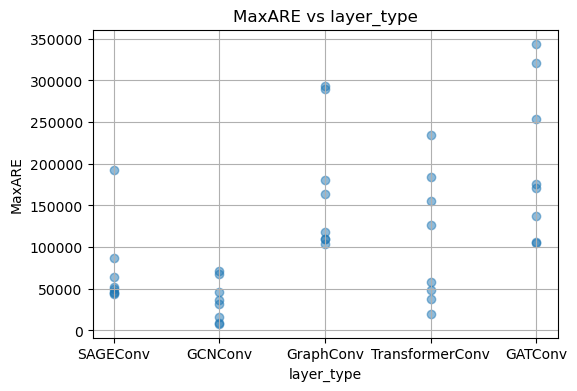

In [5]:
# Extract metrics
meanARE_values = [meanARE for _, meanARE, _ in results]
maxARE_values = [maxARE for _, _, maxARE in results]
                 
# Plot for each hyperparameter
# hyperparameters = ["n_epoch", "b_size", "hidden_size", "num_layers", "layer_type", "activation"]
hyperparameters = ["n_epoch", "layer_type"]

for hyperparameter in hyperparameters:
    plot_hyperparameter_vs_metric(configs, results, hyperparameter, 'MeanARE', meanARE_values)
    plot_hyperparameter_vs_metric(configs, results, hyperparameter, 'MaxARE', maxARE_values)

In [6]:
# Sort results by meanARE and maxARE
sorted_by_meanARE = sorted(results, key=lambda x: x[1])
sorted_by_maxARE = sorted(results, key=lambda x: x[2])

# Get top 10 models
top_10_meanARE = sorted_by_meanARE[:10]
top_10_maxARE = sorted_by_maxARE[:10]

# Load configurations for top models
top_10_meanARE_configs = load_configs(top_10_meanARE, config_dir)
top_10_maxARE_configs = load_configs(top_10_maxARE, config_dir)

# Display top 10 models
def display_top_models(top_configs, metric_name):
    print(f"Top 10 models by {metric_name}:")
    for index, meanARE, maxARE, config in top_configs:
        print(f"Index: {index}, MeanARE: {meanARE}, MaxARE: {maxARE}, Config: {config}")

display_top_models(top_10_meanARE_configs, "MeanARE")
display_top_models(top_10_maxARE_configs, "MaxARE")

Top 10 models by MeanARE:
Index: 38, MeanARE: 59.36, MaxARE: 19521.44, Config: {'l_rate': 0.001, 'w_decay': 0.0001, 'n_epoch': 1000, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 3, 'layer_type': 'TransformerConv', 'activation': 'elu'}
Index: 30, MeanARE: 74.67, MaxARE: 43373.53, Config: {'l_rate': 0.001, 'w_decay': 0.0001, 'n_epoch': 1000, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 2, 'layer_type': 'SAGEConv', 'activation': 'elu'}
Index: 1, MeanARE: 74.7, MaxARE: 8231.99, Config: {'l_rate': 0.001, 'w_decay': 0.0001, 'n_epoch': 500, 'batch_size': 32, 'hidden_size': 16, 'num_layers': 2, 'layer_type': 'GCNConv', 'activation': 'elu'}
Index: 11, MeanARE: 77.32, MaxARE: 8746.18, Config: {'l_rate': 0.001, 'w_decay': 0.0001, 'n_epoch': 500, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 2, 'layer_type': 'GCNConv', 'activation': 'elu'}
Index: 26, MeanARE: 80.37, MaxARE: 15792.11, Config: {'l_rate': 0.001, 'w_decay': 0.0001, 'n_epoch': 1000, 'batch_size': 32, 'hidden_size': 16,

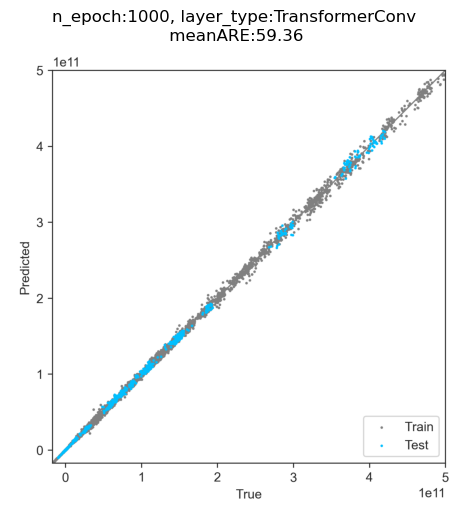

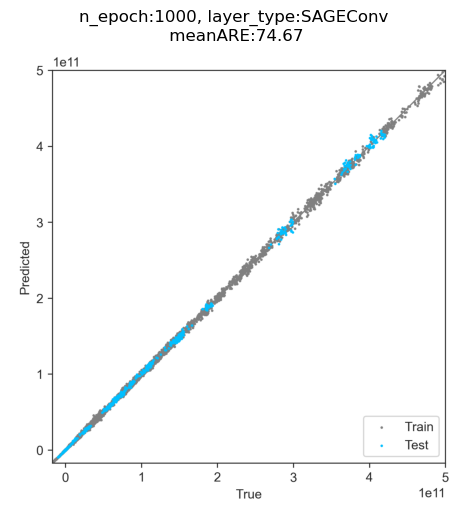

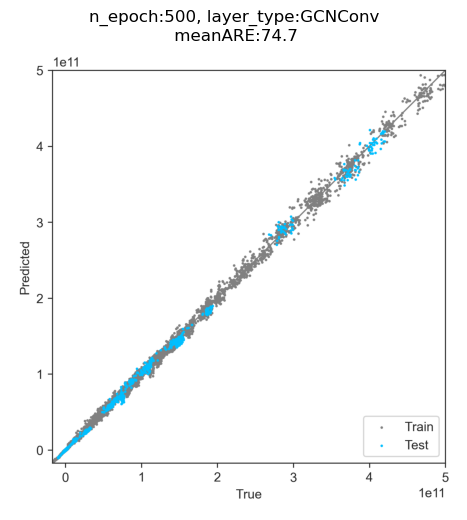

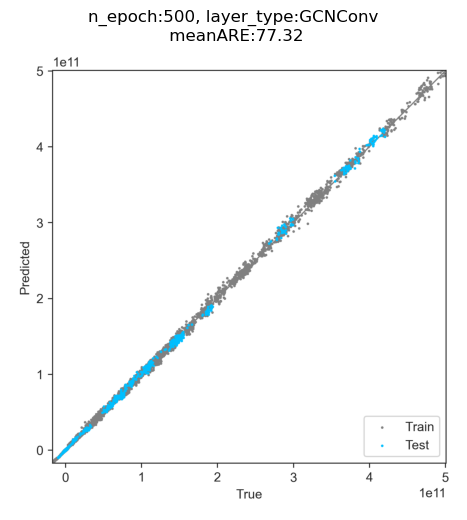

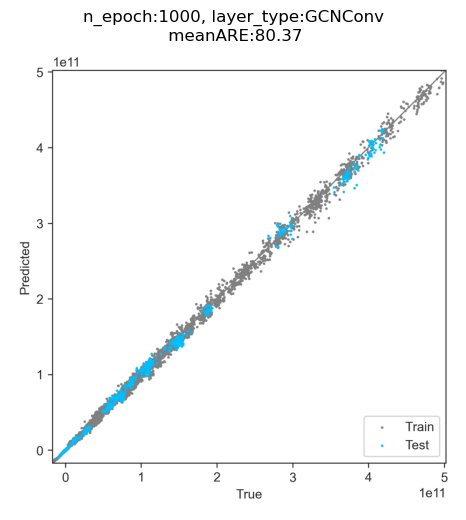

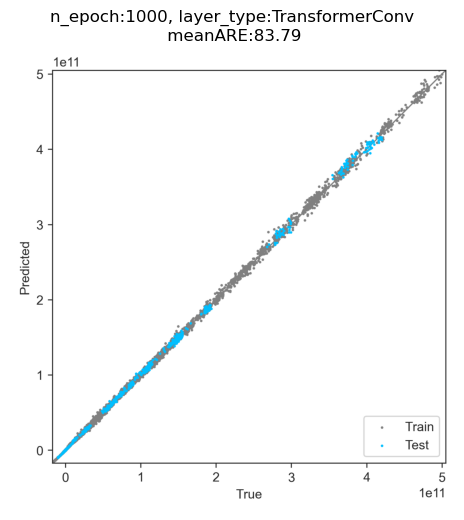

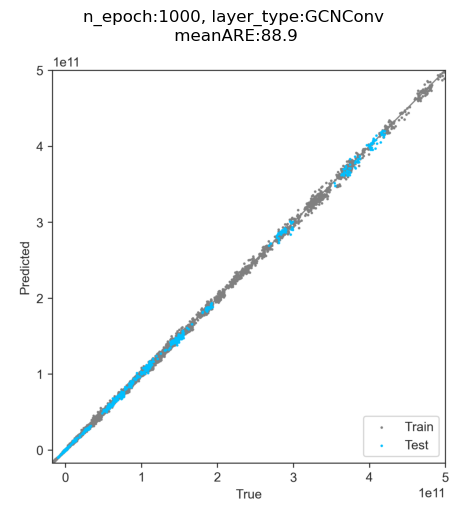

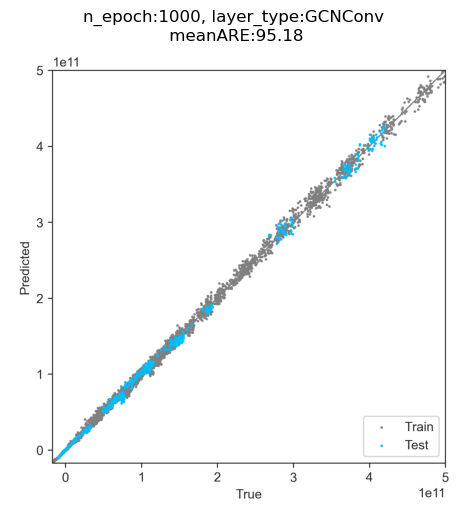

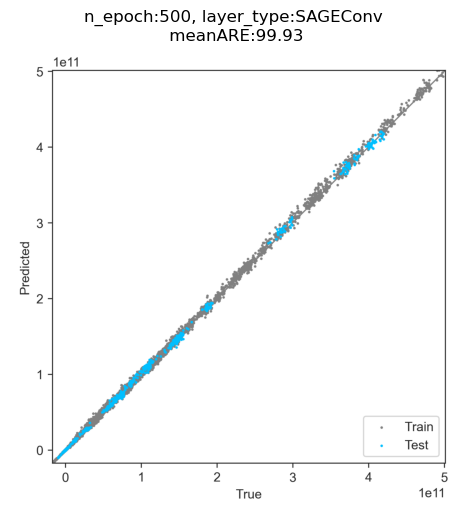

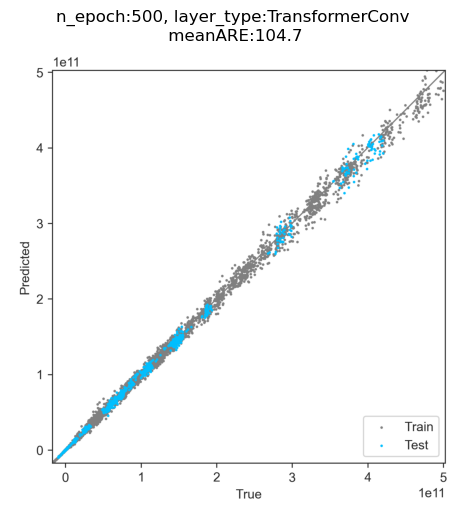

In [7]:
display_plots_for_configs("y",top_10_meanARE_configs, plots_dir, hyperparameters, value_index=1, value_name="meanARE")

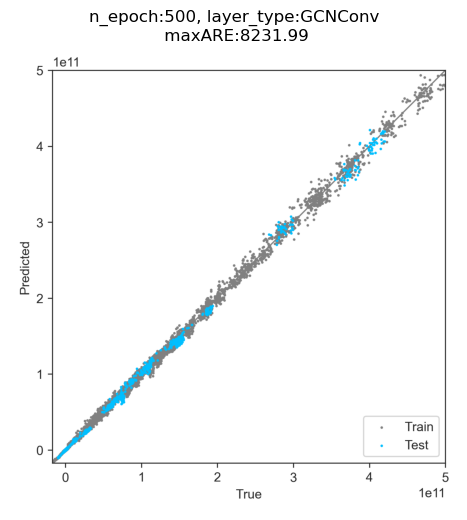

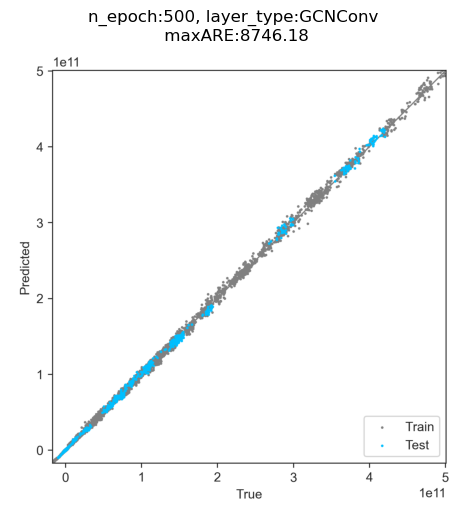

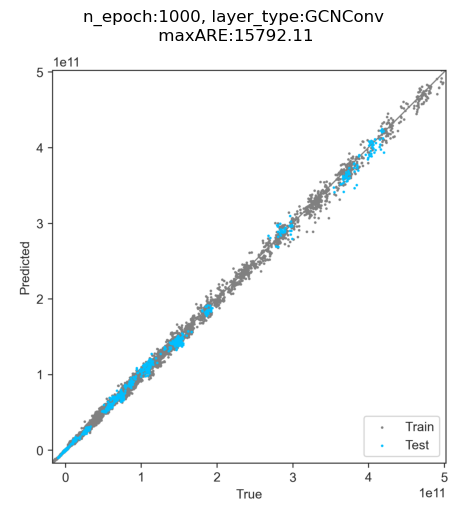

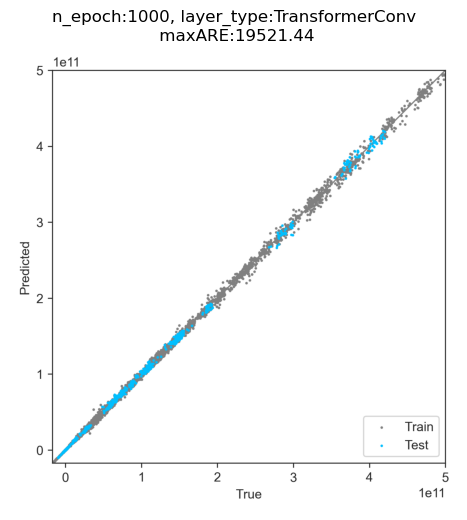

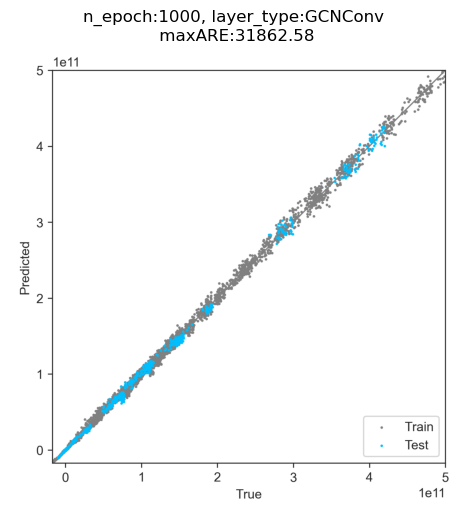

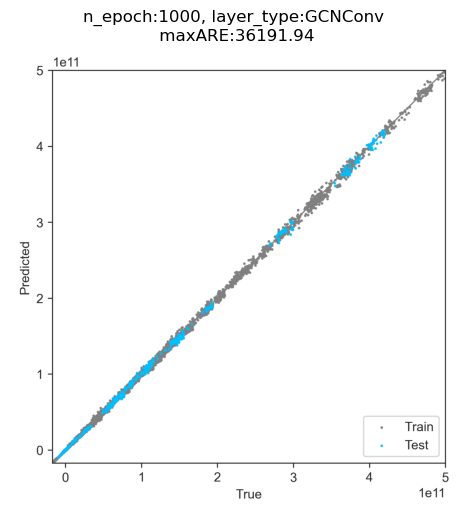

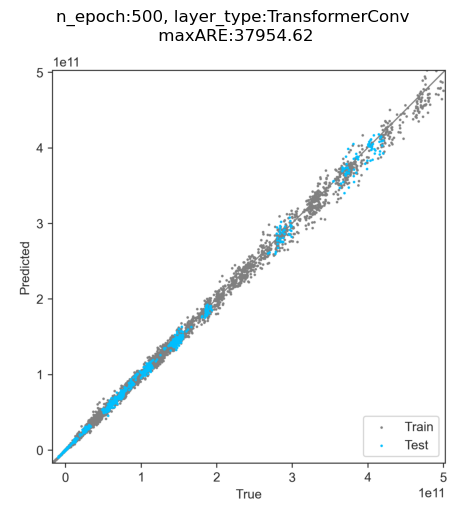

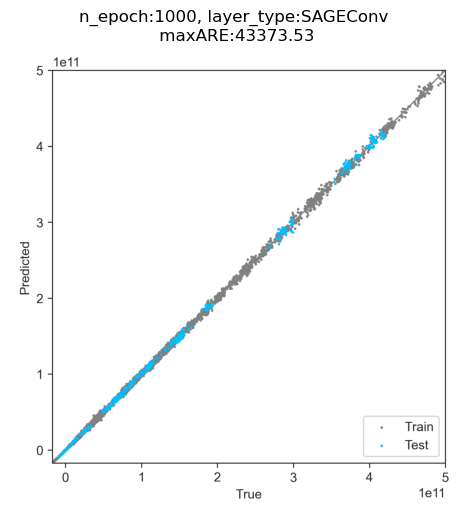

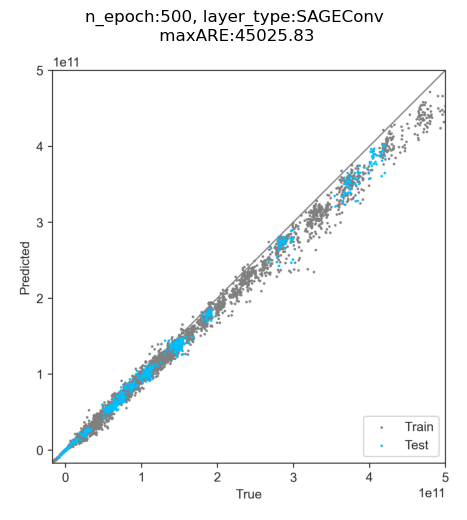

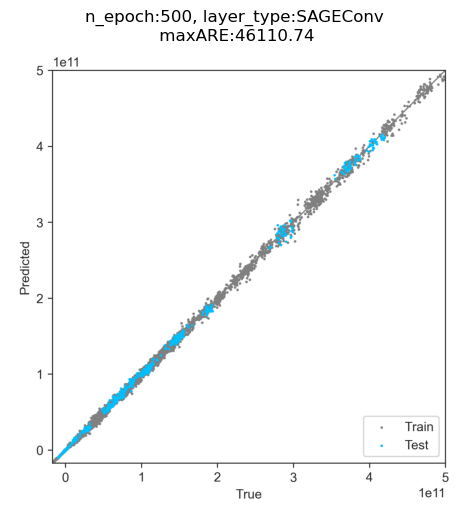

In [8]:
display_plots_for_configs("y",top_10_maxARE_configs, plots_dir, hyperparameters, value_index=2, value_name="maxARE")


### 2.Calculate MSE loss for each C element

In [134]:
import pickle
import torch
import numpy as np

from src.test import predict_and_transform_new
from src.variable import *
from src.utility_functions import msg, mean_maxARE_by_axis
from src.scaler import standard_scaling_transform
from src.io_functions import load_model, load_scalar

In [135]:
experiment_name = "test_case_7"
fold_name = ""
verbose = True
input_scaling_method = STD_SCALER
target_scaling_method = STD_SCALER

In [136]:
data_dir =  os.path.join('graph_data', experiment_name, fold_name)

train_data_filepath = os.path.join(data_dir, TRAIN_SET)
valid_data_filepath = os.path.join(data_dir, VALID_SET)
msg(f"Loading train data from {train_data_filepath}", verbose=verbose)
with open(train_data_filepath, 'rb') as f:
    train_data = pickle.load(f)
msg(f"Loading valid data from {valid_data_filepath}", verbose=verbose)
with open(valid_data_filepath, 'rb') as f:
    valid_data = pickle.load(f)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if input_scaling_method == STD_SCALER:
    attr = "x"
    input_scaler_filepath = os.path.join(output_dir, INPUT_SCALER)
    valid_data = standard_scaling_transform(valid_data, attr, input_scaler)

if target_scaling_method == STD_SCALER:
    attr = "y"
    target_scaler_filepath = os.path.join(output_dir, TARGET_SCALER)
    valid_data = standard_scaling_transform(valid_data, attr, target_scaler)

Loading train data from graph_data\test_case_7\train.pkl
Loading valid data from graph_data\test_case_7\val.pkl


In [137]:
model_name = f"config_{top_10_maxARE_configs[0][0]}.json_checkpoint.pth"

In [138]:
model_filepath = os.path.join("output", experiment_name, fold_name, "models", model_name)
model = load_model(model_filepath)

scalar_filepath = os.path.join("output", experiment_name, fold_name, TARGET_SCALER)
target_scaler = load_scalar(scalar_filepath)

c:\Users\Tansu\Documents\GitHub\MaterialPropertyPrediction\src\io_functions.py:121: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path)


In [139]:
valid_preds, valid_trues = predict_and_transform_new(model=model, 
                                                data=valid_data, 
                                                batch_size=len(valid_data), 
                                                device=device,
                                                target_scaling_method=target_scaling_method, 
                                                target_scaler=target_scaler,
                                                transform=False)

In [142]:
meanARE, maxARE = mean_maxARE_by_axis(valid_preds, valid_trues)